### CSV 파일 불러오기

In [1]:
import pandas as pd
import os

# 경로 지정
data_path = r"C:\Users\USER\Desktop\data\cleaned"

# 파일명별로 개별 불러오기
order_items = pd.read_csv(os.path.join(data_path, "order_items_EDA.csv"))
orders = pd.read_csv(os.path.join(data_path, "orders_EDA.csv"))
users = pd.read_csv(os.path.join(data_path, "users_EDA.csv"))
products = pd.read_csv(os.path.join(data_path, "products_EDA.csv"))
inventory_items = pd.read_csv(os.path.join(data_path, "inventory_items_EDA.csv"))
events = pd.read_csv(os.path.join(data_path, "events_EDA.csv"))
distribution_centers = pd.read_csv(os.path.join(data_path, "distribution_centers_EDA.csv"))

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_16292\2855328732.py:10: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  users = pd.read_csv(os.path.join(data_path, "users_EDA.csv"))


- order_items : 한 주문에 어떤 상품이 몇 개 팔렸는지
- orders : 주문 정보 (날짜, 반품여부 등)
- users : 사용자 성별, 나이, 지역 등 마케팅 인사이트
- products : 상품 카테고리, 브랜드 등 상품 정보

### 데이터 전처리 및 병합

In [4]:
# 날짜 타입으로 변환 → 시간 기준 연산을 위해
order_items['created_at'] = pd.to_datetime(order_items['created_at'])
orders['created_at'] = pd.to_datetime(orders['created_at'])

# 반품된 주문 제거 → 구매 활동 분석 시 반품은 제외해야 정확
orders_clean = orders[orders['is_returned'] == 0]

# 주문 데이터와 주문 아이템 병합 → 반품 없는 주문만 남기기
df = pd.merge(order_items, orders_clean[['order_id', 'is_returned']], on='order_id', how='inner')

# 사용자 정보 병합 → 분석 후 타겟 마케팅에 활용 가능
df = pd.merge(df, users[['id', 'gender', 'age', 'city', 'state']], left_on='user_id', right_on='id', how='left')

# 상품 정보 병합 → 브랜드나 카테고리로 추가 분석 가능
df = pd.merge(df, products[['id', 'category', 'brand']], left_on='product_id', right_on='id', how='left', suffixes=('', '_product'))

# 기준일 지정 → Recency 계산을 위한 기준일은 마지막 거래 + 1일
snapshot_date = df['created_at'].max() + pd.Timedelta(days=1)

### RFM지표 계산하기

In [6]:
rfm = df.groupby('user_id').agg({
    'created_at': lambda x: (snapshot_date - x.max()).days,     # Recency
    'order_id': 'nunique',                                      # Frequency
    'sale_price': 'sum'                                         # Monetary
}).reset_index()

rfm.columns = ['user_id', 'Recency', 'Frequency', 'Monetary']


- Recency : 최근 구매일로부터의 날짜 수 -> 작을수록 최근 구매자
- Frequency : 총 구매 횟수 -> 많을수록 우수고객
- Monetary : 총 구매 금액

### RFM 점수화 + 고객 세그먼트 분류

In [9]:
# 5등급으로 분류 → 가장 좋은 값이 5, 낮은 게 1
rfm['R'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

# 세 점수를 합쳐서 점수 문자열 만들기
rfm['RFM_Score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

# 점수 조합에 따른 고객 분류
def segment(row):
    if row['RFM_Score'] == '555':
        return 'Platinum'
    elif int(row['R']) >= 4 and int(row['F']) >= 4:
        return 'Gold'
    elif int(row['R']) >= 4:
        return 'Silver'
    elif int(row['M']) >= 4:
        return 'Bronze'
    else:
        return 'Iron'

rfm['Segment'] = rfm.apply(segment, axis=1)

- 5분위로 나눠서 상대적인 비교 가능
- 555(RFM)이 최고점수


### 사용자 특성 + 세그먼트 연결

In [12]:
# demographic 정보로 세그먼트 해석 풍부하게
rfm_full = pd.merge(rfm, users[['id', 'age', 'gender', 'state', 'city']], left_on='user_id', right_on='id', how='left')

- 나이/성별/지역별로 어떤 세그먼트가 많은지 파악 가능

### 시각화

In [15]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import platform

# 시스템에 따라 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 기본 한글 폰트
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'    # 맥 기본 한글 폰트
else:
    plt.rcParams['font.family'] = 'NanumGothic'     # 리눅스 또는 Google Colab 등

# 마이너스 기호 깨짐 방지
mpl.rcParams['axes.unicode_minus'] = False

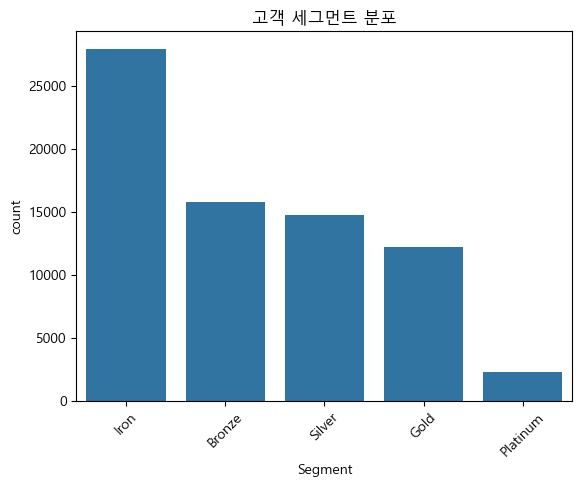

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# 세그먼트별 분포
sns.countplot(data=rfm_full, x='Segment', order=rfm_full['Segment'].value_counts().index)
plt.title("고객 세그먼트 분포")
plt.xticks(rotation=45)
plt.show()

In [17]:
# 기본 통계량 출력
print(" RFM 지표 요약")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

# RFM 점수별 분포
print("\n R 점수 분포")
print(rfm['R'].value_counts().sort_index())

print("\n F 점수 분포")
print(rfm['F'].value_counts().sort_index())

print("\n M 점수 분포")
print(rfm['M'].value_counts().sort_index())

# 세그먼트 분포
print("\n 고객 세그먼트 분포")
print(rfm['Segment'].value_counts())

 RFM 지표 요약
            Recency     Frequency      Monetary
count  73043.000000  73043.000000  73043.000000
mean     400.066618      1.505113    129.945394
std      378.394242      0.803125    134.208465
min        1.000000      1.000000      0.490000
25%       98.000000      1.000000     39.990002
50%      278.000000      1.000000     86.090000
75%      597.000000      2.000000    174.135002
max     1841.000000      4.000000   1738.969982

 R 점수 분포
R
5    14640
4    14601
3    14616
2    14586
1    14600
Name: count, dtype: int64

 F 점수 분포
F
1    14609
2    14608
3    14609
4    14608
5    14609
Name: count, dtype: int64

 M 점수 분포
M
1    14610
2    14610
3    14607
4    14607
5    14609
Name: count, dtype: int64

 고객 세그먼트 분포
Segment
Iron        27983
Bronze      15819
Silver      14749
Gold        12188
Platinum     2304
Name: count, dtype: int64


### 연령대/성별/지역 별 세그먼트 분포 시각화

In [19]:
# 연령 구간 만들기
rfm_full['age_group'] = pd.cut(rfm_full['age'], bins=[0, 20, 30, 40, 50, 60, 100], labels=['10대', '20대', '30대', '40대', '50대', '60대+'])

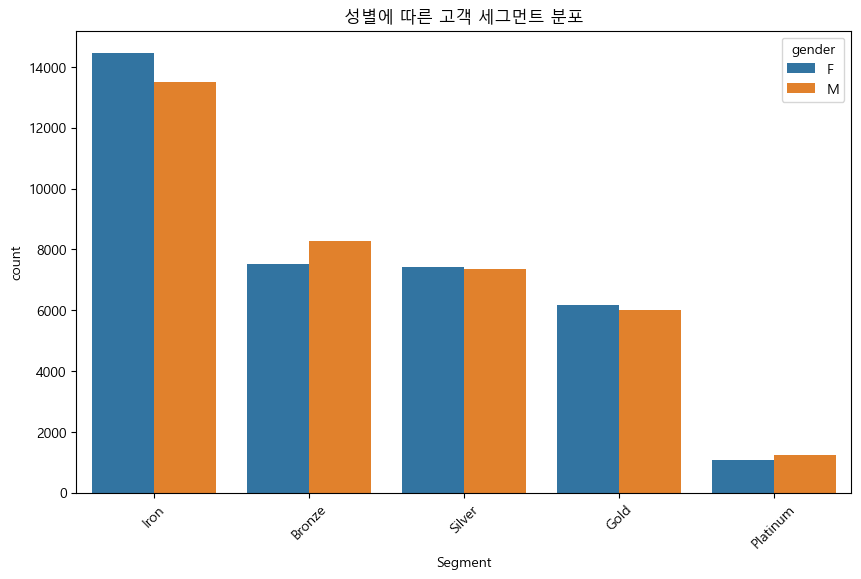

In [20]:
plt.figure(figsize=(10,6))
sns.countplot(data=rfm_full, x='Segment', hue='gender', order=rfm['Segment'].value_counts().index)
plt.title("성별에 따른 고객 세그먼트 분포")
plt.xticks(rotation=45)
plt.show()

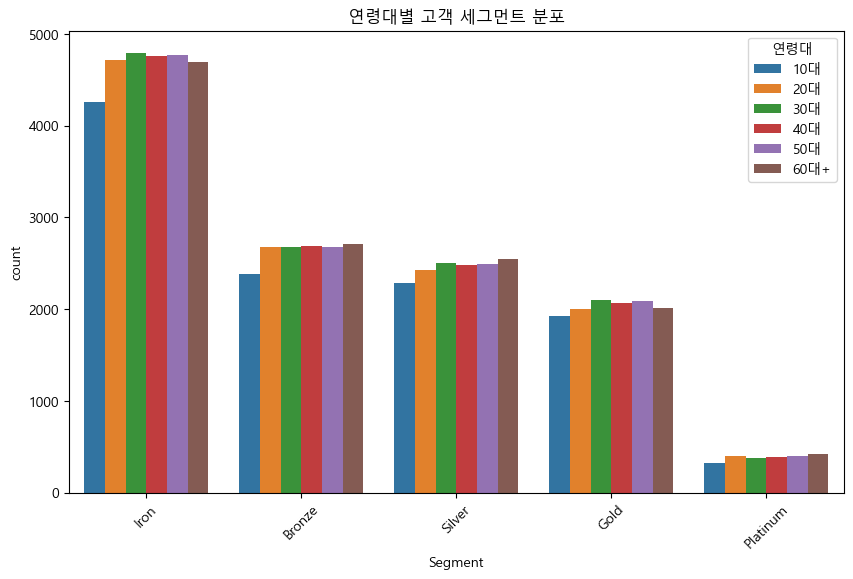

In [21]:
plt.figure(figsize=(10,6))
sns.countplot(data=rfm_full, x='Segment', hue='age_group', order=rfm['Segment'].value_counts().index)
plt.title("연령대별 고객 세그먼트 분포")
plt.xticks(rotation=45)
plt.legend(title='연령대')
plt.show()

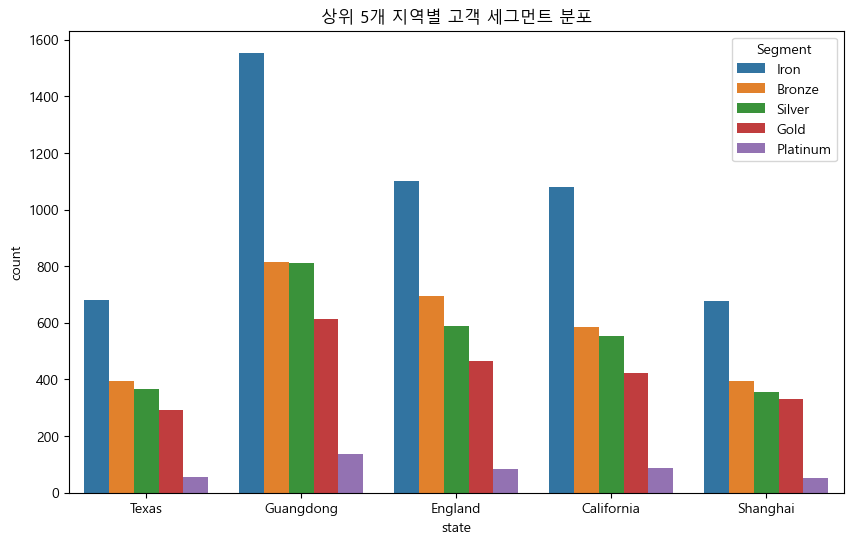

In [22]:
top_states = rfm_full['state'].value_counts().head(5).index

plt.figure(figsize=(10,6))
sns.countplot(data=rfm_full[rfm_full['state'].isin(top_states)],
              x='state', hue='Segment',
              hue_order=rfm['Segment'].value_counts().index)
plt.title("상위 5개 지역별 고객 세그먼트 분포")
plt.xticks(rotation=0)
plt.legend(title='Segment')
plt.show()

### RFM 평균값 구하기

In [24]:
# 원하는 세그먼트 순서 정의
segment_order = ['Platinum', 'Gold', 'Silver', 'Bronze', 'Iron']

In [25]:
# Segment 순서대로 정렬된 평균값 테이블 생성
rfm_segment_summary = (
    rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']]
    .mean()
    .round(2)
    .reindex(segment_order)
)

print(" 세그먼트별 RFM 평균값")
print(rfm_segment_summary)


 세그먼트별 RFM 평균값
          Recency  Frequency  Monetary
Segment                               
Platinum    33.06       3.19    363.62
Gold        86.61       2.25    179.07
Silver      85.81       1.00     87.26
Bronze     572.14       1.78    237.75
Iron       635.17       1.15     50.86


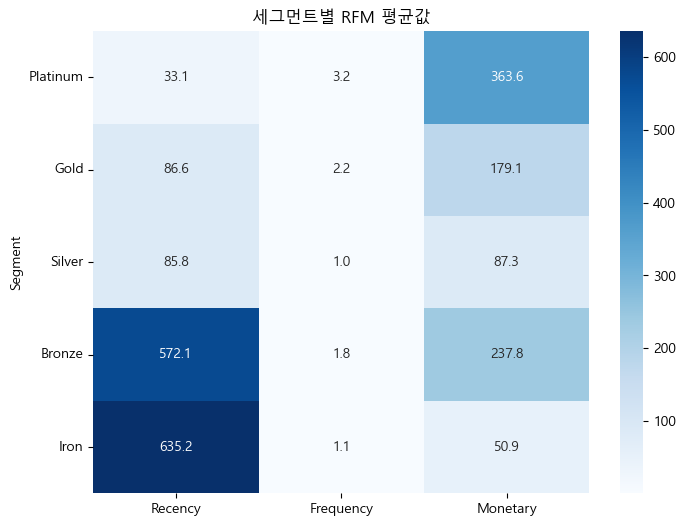

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(rfm_segment_summary, annot=True, fmt=".1f", cmap='Blues')
plt.title("세그먼트별 RFM 평균값")
plt.yticks(rotation=0)
plt.show()

### 통계적으로 유의미한지 검증

- ANOVA(분산분석) : 등급 간 평균 차이 검정 -> 연속형 값에 대해 등급이 영향을 주는지
- 사후검정(Turkey HSD) : 어떤 등급끼리 차이가 나는지 확인 -> ANOVA에서 유의미한 차이가 있으면 수행
- Chi-square test : 성별/지역 등 범주형 변수와 Segment와의 연관성 확인 -> 범주형 변수와의 관련성 분석 시

In [29]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway, levene
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns

- 데이터 기본 확인

In [31]:
print(rfm_full[['Segment', 'Recency', 'Frequency', 'Monetary']].head())
print(rfm_full['Segment'].value_counts())

  Segment  Recency  Frequency    Monetary
0  Bronze      551          1  159.990000
1    Iron      701          1   22.000000
2    Gold      167          4  402.200001
3  Bronze      461          1  148.000000
4    Iron      455          1   65.650000
Segment
Iron        27983
Bronze      15819
Silver      14749
Gold        12188
Platinum     2304
Name: count, dtype: int64


- 등급별 각 지표 분포 시각화 (박스플롯, 히스토그램)

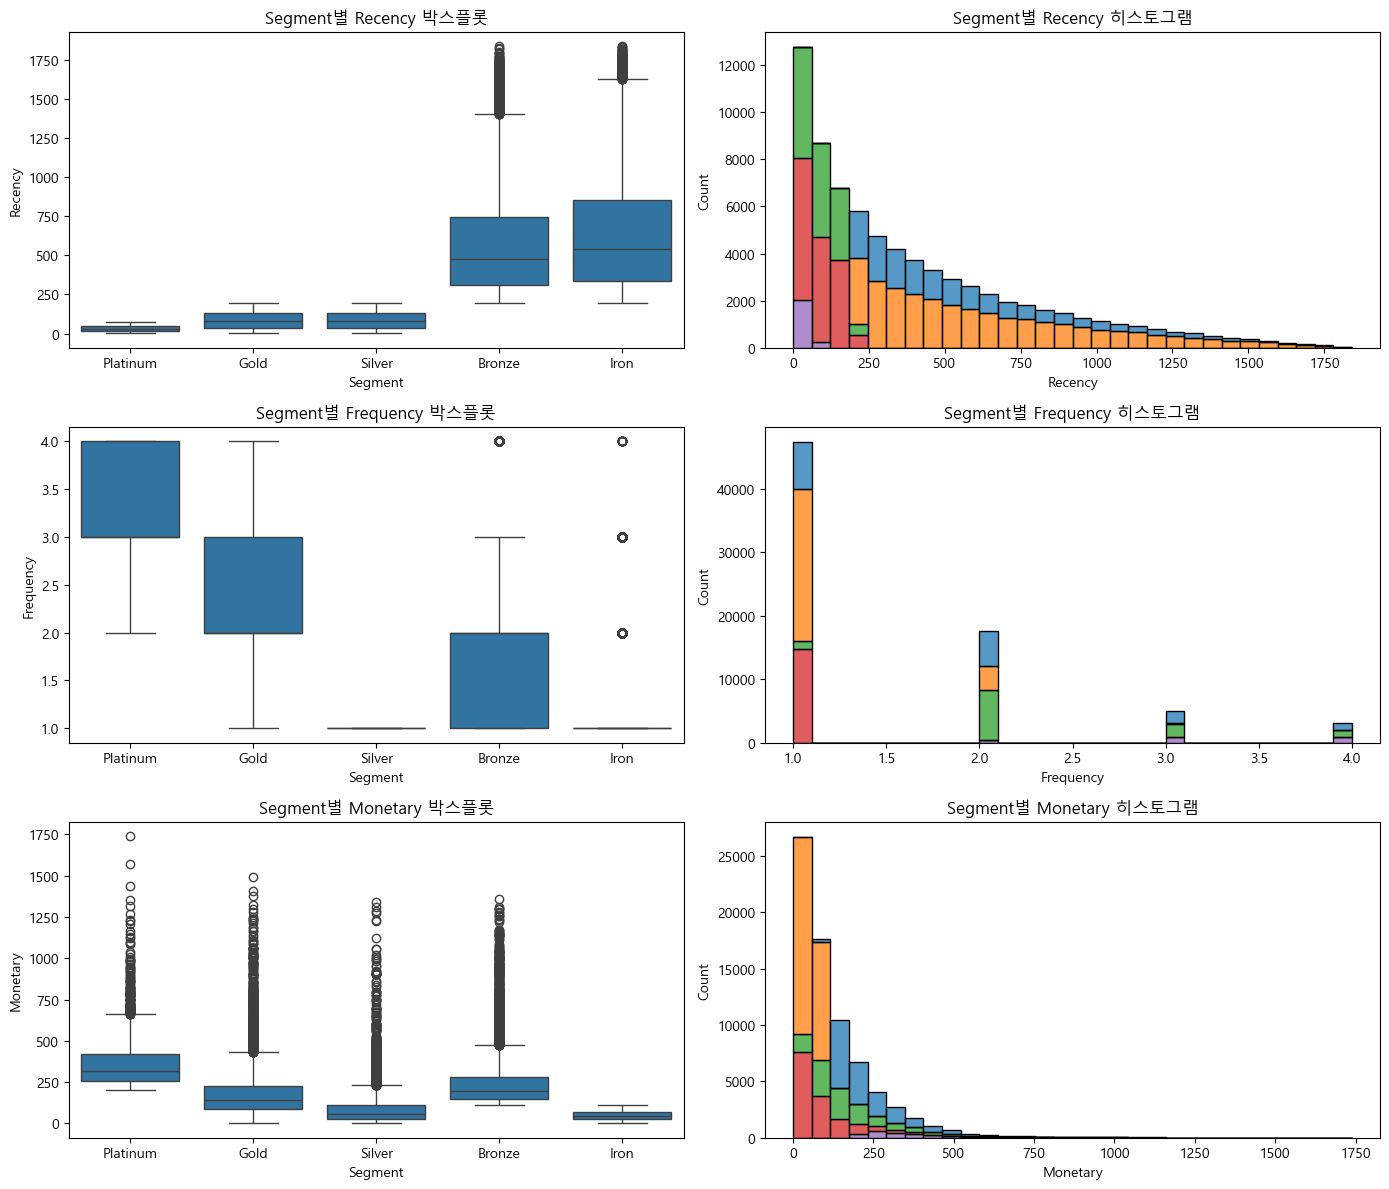

In [33]:
fig, axs = plt.subplots(3, 2, figsize=(14, 12))

for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    sns.boxplot(x='Segment', y=col, data=rfm_full, order=segment_order, ax=axs[i, 0])
    axs[i, 0].set_title(f'Segment별 {col} 박스플롯')
    
    sns.histplot(data=rfm_full, x=col, hue='Segment', multiple='stack', palette='tab10', bins=30, ax=axs[i, 1], legend=False)
    axs[i, 1].set_title(f'Segment별 {col} 히스토그램')

plt.tight_layout()
plt.show()

- 등분산성 검사

In [35]:
for col in ['Recency', 'Frequency', 'Monetary']:
    groups = [rfm_full[rfm_full['Segment'] == seg][col] for seg in segment_order]
    stat, p = levene(*groups)
    print(f"{col} 등분산성 검사 - Levene Test p-value: {p:.4f}")

Recency 등분산성 검사 - Levene Test p-value: 0.0000
Frequency 등분산성 검사 - Levene Test p-value: 0.0000
Monetary 등분산성 검사 - Levene Test p-value: 0.0000


- p-value가 0이 나왔으므로 Kruskal-Wallis검정 진행

In [37]:
from scipy.stats import kruskal

segment_order = ['Platinum', 'Gold', 'Silver', 'Bronze', 'Iron']

for col in ['Recency', 'Frequency', 'Monetary']:
    groups = [rfm_full[rfm_full['Segment'] == seg][col] for seg in segment_order]
    stat, p_value = kruskal(*groups)
    print(f"\n{col} Kruskal-Wallis 검정 결과")
    print(f"Statistic: {stat:.3f}")
    print(f"P-value: {p_value:.4f}")
    if p_value < 0.05:
        print(f" {col} 값은 Segment별로 유의미한 차이가 있습니다.")
    else:
        print(f" {col} 값은 Segment별로 유의미한 차이가 없습니다.")


Recency Kruskal-Wallis 검정 결과
Statistic: 53046.482
P-value: 0.0000
 Recency 값은 Segment별로 유의미한 차이가 있습니다.

Frequency Kruskal-Wallis 검정 결과
Statistic: 37028.425
P-value: 0.0000
 Frequency 값은 Segment별로 유의미한 차이가 있습니다.

Monetary Kruskal-Wallis 검정 결과
Statistic: 40398.110
P-value: 0.0000
 Monetary 값은 Segment별로 유의미한 차이가 있습니다.


In [38]:
pip install scikit-posthocs

Note: you may need to restart the kernel to use updated packages.


In [39]:
import scikit_posthocs as sp

for col in ['Recency', 'Frequency', 'Monetary']:
    print(f"\n--- {col} Dunn 사후검정 ---")
    dunn = sp.posthoc_dunn(rfm_full, val_col=col, group_col='Segment', p_adjust='bonferroni')
    print(dunn)


--- Recency Dunn 사후검정 ---
                Bronze          Gold          Iron      Platinum        Silver
Bronze    1.000000e+00  0.000000e+00  7.049700e-25  0.000000e+00  0.000000e+00
Gold      0.000000e+00  1.000000e+00  0.000000e+00  6.507100e-68  1.000000e+00
Iron      7.049700e-25  0.000000e+00  1.000000e+00  0.000000e+00  0.000000e+00
Platinum  0.000000e+00  6.507100e-68  0.000000e+00  1.000000e+00  1.808287e-67
Silver    0.000000e+00  1.000000e+00  0.000000e+00  1.808287e-67  1.000000e+00

--- Frequency Dunn 사후검정 ---
          Bronze           Gold           Iron       Platinum         Silver
Bronze       1.0   0.000000e+00   0.000000e+00   0.000000e+00   0.000000e+00
Gold         0.0   1.000000e+00   0.000000e+00  5.034871e-146   0.000000e+00
Iron         0.0   0.000000e+00   1.000000e+00   0.000000e+00  1.042874e-152
Platinum     0.0  5.034871e-146   0.000000e+00   1.000000e+00   0.000000e+00
Silver       0.0   0.000000e+00  1.042874e-152   0.000000e+00   1.000000e+00

--- Mon

- Recency, Frequency, Monetary 세 지표 모두 등급별로 통계적으로 유의미한 차이가 확인되었다.
- 사후검정 결과 대부분의 세그먼트 간 RFM지표 차이가 유의미하게 나타났으며, (p<0.05)이는 각 고객 특성이 명확히 구분된다는 뜻.
- 일부 구간에서는 차이가 없거나 미미한 경우도 있지만, 대체로 세분화가 효과적임을 보여준다.

### 통계적으로 유의미하다는 것을 알았으니 추가분석

- 세그먼트 별 재구매율 계산

In [43]:
# 재구매 여부를 판단할 기준: 한 명이 주문을 2회 이상 했으면 재구매 고객으로 간주

# 1) 고객별 주문 수 집계 (order_items_EDA 또는 orders_EDA 활용)
order_counts = order_items.groupby('user_id')['order_id'].nunique().reset_index()
order_counts.columns = ['user_id', 'order_count']

# 2) 재구매 여부 컬럼 추가
order_counts['is_repeat'] = order_counts['order_count'] > 1

# 3) rfm_full에 사용자 세그먼트 정보가 있으므로 결합
repeat_info = pd.merge(order_counts, rfm_full[['user_id', 'Segment']], on='user_id', how='left')

# 4) 세그먼트별 재구매율 계산
repeat_rate = repeat_info.groupby('Segment')['is_repeat'].mean().reset_index()
repeat_rate.columns = ['Segment', 'Repeat_Rate']

print(repeat_rate)

    Segment  Repeat_Rate
0    Bronze     0.565333
1      Gold     0.907532
2      Iron     0.208484
3  Platinum     1.000000
4    Silver     0.078785


- 세그먼트 별 평균 주문 금액 계산

In [46]:
# 고객별 총 구매액, 주문 건수 구하기
total_sales = order_items.groupby('user_id')['sale_price'].sum().reset_index()
order_counts = order_items.groupby('user_id')['order_id'].nunique().reset_index()

customer_sales = pd.merge(total_sales, order_counts, on='user_id')
customer_sales['avg_order_amount'] = customer_sales['sale_price'] / customer_sales['order_id']

# 세그먼트 정보 결합
sales_info = pd.merge(customer_sales[['user_id', 'avg_order_amount']], rfm_full[['user_id', 'Segment']], on='user_id', how='left')

# 세그먼트별 평균 주문 금액
avg_order_amount = sales_info.groupby('Segment')['avg_order_amount'].mean().reset_index()
avg_order_amount.columns = ['Segment', 'Avg_Order_Amount']

print(avg_order_amount)

    Segment  Avg_Order_Amount
0    Bronze        154.333495
1      Gold         81.360279
2      Iron         46.890497
3  Platinum        117.856188
4    Silver         87.117243


### 고객 생애가치(LTV) 추정 및 예측

In [49]:
# 1. 고객별 총 매출과 총 주문 수 계산 (order_items_EDA 기준, user_id, sale_price 필요)
customer_sales = order_items.groupby('user_id').agg(
    total_revenue=('sale_price', 'sum'),
    total_orders=('order_id', 'nunique'),
).reset_index()

# 2. 고객별 첫 주문, 마지막 주문 날짜 계산 (orders_EDA 기준, user_id, created_at 필요)
orders['created_at'] = pd.to_datetime(orders['created_at'])
customer_order_dates = orders.groupby('user_id').agg(
    first_order_date=('created_at', 'min'),
    last_order_date=('created_at', 'max'),
).reset_index()

# 3. 고객 유지기간 계산 (일 단위)
customer_order_dates['lifespan_days'] = (customer_order_dates['last_order_date'] - customer_order_dates['first_order_date']).dt.days + 1

# 4. 고객별 LTV 계산 (일 단위를 월 단위로 환산)
customer_df = pd.merge(customer_sales, customer_order_dates, on='user_id')
customer_df['purchase_frequency'] = customer_df['total_orders'] / (customer_df['lifespan_days'] / 30)  # 월별 구매 빈도
customer_df['avg_order_value'] = customer_df['total_revenue'] / customer_df['total_orders']
customer_df['LTV'] = customer_df['avg_order_value'] * customer_df['purchase_frequency'] * (customer_df['lifespan_days'] / 30)

# 5. rfm_full 또는 별도의 데이터프레임에서 user_id와 Segment를 merge
customer_df = pd.merge(customer_df, rfm_full[['user_id', 'Segment']], on='user_id', how='left')

# 6. 세그먼트별 평균 LTV 확인
ltv_segment = customer_df.groupby('Segment')['LTV'].mean().reset_index().sort_values(by='LTV', ascending=False)

print(ltv_segment)

    Segment         LTV
3  Platinum  374.011281
0    Bronze  247.245330
1      Gold  189.641155
4    Silver   94.502217
2      Iron   58.093950


- total_revenue: 고객이 지금까지 낸 총 매출

- total_orders: 고객이 지금까지 한 주문 횟수

- lifespan_days: 첫 주문부터 마지막 주문까지 기간

- purchase_frequency: 월 단위 구매 빈도 (구매 횟수 / 월수)

- avg_order_value: 주문당 평균 매출

- LTV: 고객 생애가치 (월별 구매 빈도 × 평균 주문 금액 × 고객 유지 개월 수)

### 세그먼트 별 이탈율 계산

In [59]:
# 기준일 정의 (UTC 포함)
reference_date = pd.to_datetime('2023-01-01').tz_localize('UTC')

# 1. 고객별 마지막 주문일 구하기
last_order_date = orders.groupby('user_id')['created_at'].max().reset_index()
last_order_date['created_at'] = pd.to_datetime(last_order_date['created_at']).dt.tz_convert('UTC')

# 2. 기준일로부터 6개월 이상 주문 없으면 이탈로 간주
last_order_date['is_churn'] = last_order_date['created_at'] < (reference_date - pd.DateOffset(months=6))

# 3. Segment 정보 병합
last_order_date = last_order_date.merge(rfm_full[['user_id', 'Segment']], on='user_id', how='left')

# 4. 세그먼트별 이탈률 계산
churn_summary = last_order_date.groupby('Segment')['is_churn'].agg(
    total_users='count',
    churned_users='sum'
).reset_index()

churn_summary['churn_rate'] = churn_summary['churned_users'] / churn_summary['total_users']

print(churn_summary)

    Segment  total_users  churned_users  churn_rate
0    Bronze        15819           5990    0.378659
1      Gold        12188              0    0.000000
2      Iron        27983          12611    0.450666
3  Platinum         2304              0    0.000000
4    Silver        14749              0    0.000000


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_16292\4055266964.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0%}'.format(x) for x in plt.gca().get_yticks()])


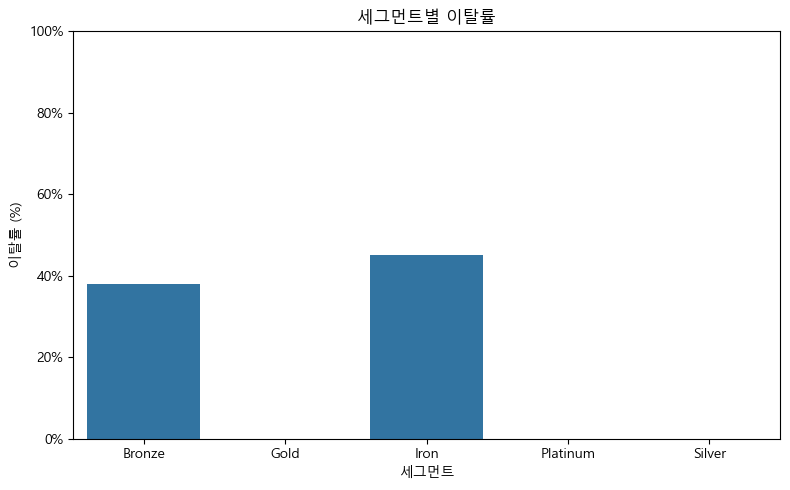

In [61]:
plt.figure(figsize=(8, 5))
sns.barplot(data=churn_summary, x='Segment', y='churn_rate', order=churn_summary['Segment'])
plt.title('세그먼트별 이탈률')
plt.ylabel('이탈률 (%)')
plt.xlabel('세그먼트')
plt.ylim(0, 1)
plt.gca().set_yticklabels(['{:.0%}'.format(x) for x in plt.gca().get_yticks()])
plt.tight_layout()
plt.show()

- 이탈률이 높은 세그먼트는 타겟 리텐션 마케팅 전략의 핵심 대상이다.(예: ‘Iron’이나 ‘Bronze’ 고객에게 리마인드 캠페인, 할인 쿠폰 제공)

- 이탈률이 낮고 LTV가 높은 세그먼트는 핵심 충성고객. (예: ‘Platinum’, ‘Gold’ → VIP 프로그램 제공)

### RFM + LTV + 세그먼트별 이탈율

In [71]:
import pandas as pd

# 파일 불러오기
orders = pd.read_csv('C:/Users/USER/Desktop/data/cleaned/orders_EDA.csv', parse_dates=['created_at'])
order_items = pd.read_csv('C:/Users/USER/Desktop/data/cleaned/order_items_EDA.csv', parse_dates=['created_at'])

In [75]:
# 1. Recency: 고객별 마지막 주문일 기준
import pytz
reference_date = pd.to_datetime('2023-01-01').tz_localize('UTC')
recency_df = orders.groupby('user_id')['created_at'].max().reset_index()
recency_df['Recency'] = (reference_date - recency_df['created_at']).dt.days

# 2. Frequency: 고객별 주문 횟수
frequency_df = orders.groupby('user_id')['order_id'].nunique().reset_index()
frequency_df.rename(columns={'order_id': 'Frequency'}, inplace=True)

# 3. Monetary: order_items의 sale_price 기반
monetary_df = order_items.groupby('user_id')['sale_price'].sum().reset_index()
monetary_df.rename(columns={'sale_price': 'Monetary'}, inplace=True)

# 4. 병합
rfm = recency_df[['user_id', 'Recency']] \
    .merge(frequency_df, on='user_id') \
    .merge(monetary_df, on='user_id')

In [77]:
# 각 지표별 quantile 분할
rfm['R'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M'] = pd.qcut(rfm['Monetary'].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)

# RFM Score
rfm['RFM_Score'] = rfm[['R','F','M']].sum(axis=1)

# Segment 부여 (예시: 점수 기준)
def assign_segment(score):
    if score >= 13:
        return 'Platinum'
    elif score >= 10:
        return 'Gold'
    elif score >= 6:
        return 'Silver'
    elif score >= 4:
        return 'Bronze'
    else:
        return 'Iron'

rfm['Segment'] = rfm['RFM_Score'].apply(assign_segment)

In [79]:
# LTV = Monetary * Frequency (기초적 정의)
rfm['LTV'] = rfm['Monetary'] * rfm['Frequency']

# 세그먼트별 평균 LTV
ltv_by_segment = rfm.groupby('Segment')['LTV'].mean().reset_index().sort_values(by='LTV', ascending=False)
print(ltv_by_segment)

    Segment         LTV
3  Platinum  881.421058
1      Gold  344.528194
4    Silver   90.671899
0    Bronze   36.289801
2      Iron   21.290589


In [81]:
# 사용자별 마지막 주문일 기준
last_order_date = orders.groupby('user_id')['created_at'].max().reset_index()
last_order_date['created_at'] = pd.to_datetime(last_order_date['created_at'])

# 기준일 6개월 이상 전이면 이탈로 간주
last_order_date['is_churn'] = last_order_date['created_at'] < (reference_date - pd.DateOffset(months=6))

# Segment 정보 병합
last_order_date = last_order_date.merge(rfm[['user_id', 'Segment']], on='user_id', how='left')

# 세그먼트별 이탈률 계산
churn_summary = last_order_date.groupby('Segment')['is_churn'].agg(
    total_users='count',
    churned_users='sum'
).reset_index()
churn_summary['churn_rate'] = churn_summary['churned_users'] / churn_summary['total_users']

print(churn_summary.sort_values(by='churn_rate', ascending=False))

    Segment  total_users  churned_users  churn_rate
2      Iron         1256           1256    1.000000
0    Bronze         9441           6402    0.678106
4    Silver        34212           9984    0.291827
1      Gold        20885           2556    0.122384
3  Platinum        12343              0    0.000000


In [85]:
rfm_full['LTV'] = rfm_full['Frequency'] * rfm_full['Monetary']

In [87]:
# 1. LTV 집계
ltv_df = rfm_full.groupby('Segment')['LTV'].mean().reset_index()
ltv_df.rename(columns={'LTV': 'avg_LTV'}, inplace=True)

# 2. 이탈률 집계
churn_df = last_order_date.groupby('Segment')['is_churn'].agg(
    total_users='count',
    churned_users='sum'
).reset_index()
churn_df['churn_rate'] = churn_df['churned_users'] / churn_df['total_users']

# 3. 병합
priority_df = pd.merge(ltv_df, churn_df[['Segment', 'churn_rate']], on='Segment')
print(priority_df)

    Segment      avg_LTV  churn_rate
0    Bronze   456.795819    0.678106
1      Gold   440.594063    0.122384
2      Iron    62.617157    1.000000
3  Platinum  1181.129736    0.000000
4    Silver    87.263190    0.291827


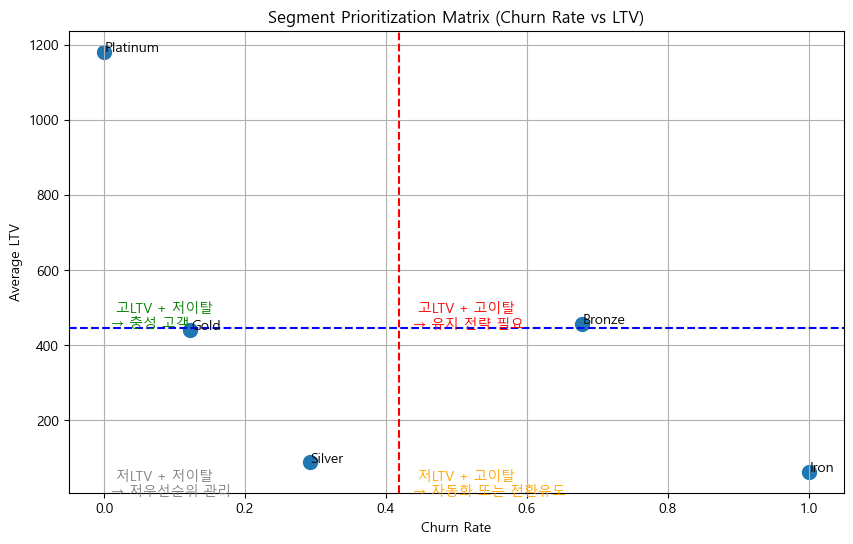

In [91]:
# 우선순위 기준선 (평균값으로 설정)
x_mean = priority_df['churn_rate'].mean()
y_mean = priority_df['avg_LTV'].mean()

plt.figure(figsize=(10, 6))
plt.scatter(priority_df['churn_rate'], priority_df['avg_LTV'], s=100)

# 라벨 표시
for i in range(len(priority_df)):
    plt.text(priority_df['churn_rate'][i] + 0.001,
             priority_df['avg_LTV'][i] + 0.01,
             priority_df['Segment'][i],
             fontsize=10)

# 기준선
plt.axvline(x=x_mean, color='red', linestyle='--')
plt.axhline(y=y_mean, color='blue', linestyle='--')

# 제목/축
plt.title('Segment Prioritization Matrix (Churn Rate vs LTV)')
plt.xlabel('Churn Rate')
plt.ylabel('Average LTV')

# 전략적 사분면 설명 (optional 주석)
plt.text(x_mean + 0.02, y_mean + 0.02, ' 고LTV + 고이탈\n→ 유지 전략 필요', color='red')
plt.text(0.01, y_mean + 0.02, ' 고LTV + 저이탈\n→ 충성 고객', color='green')
plt.text(x_mean + 0.02, 0.01, ' 저LTV + 고이탈\n→ 자동화 또는 전환유도', color='orange')
plt.text(0.01, 0.01, ' 저LTV + 저이탈\n→ 저우선순위 관리', color='gray')

plt.grid(True)
plt.show()

#### 고LTV + 고 이탈율
- 특징 : 고객 가치는 높지만, 이탈 가능성도 높음
    - 맞춤형 혜택
    - 적극적인 커뮤니케이션
    - 이탈이유 파악을 통한 문제 해결
    - 충성도 강화 캠폐인 등

#### 고LTV + 저 이탈율
- 특징 : 가치도 높고, 안정적으로 유지되는 고객군
    - 기존 만족도 유지 및 강화
    - 추가 교차 판매, 업셀링 전략 추진
    - 브랜드 홍보 강화
    - 장기적 관계 유지를 위한 맞춤형 혜택 제공

#### 저LTV + 고 이탈율
- 특징 : 고객 가치 낮고, 이탈율도 높음
    - 비용 효율적인 자동화 마케팅 적용 (이메일, 푸시알람 등)
    - 고객 전환 유도 프로모션 (할인 등)
    - 무리한 투자는 지양
    - 잠재 가치가 있는 고객인지 추가적인 분석 필요

### 저LTV + 저 이탈율
- 특징 : 고객 가치는 낮으나 비교적 안정적인 고객
    - 최소한의 유지비용으로 관리
    - 필요 시 고객 세분화 재검토
    - 신규 고객 유입 / 육성에 집중하는 것이 더 효과적